In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

In [3]:
import matplotlib.pyplot as plt

# SI3014 — Tiny ImageNet Competition

In this activity you will build, train, compare, and improve neural networks for **200-class image classification** on Tiny ImageNet.

## Goal

You must implement two models:

1. **FCNN / MLP:** a fully connected neural network **without convolutional layers**.
2. **CNN:** a convolutional neural network that exploits the spatial structure of images.

At the end, select your best model using the **validation set**, generate `submission.csv`, and submit it to the Kaggle competition.

## Rules

- **Model 1 cannot use convolutional layers.**
- **Model 2 must use convolutional layers.**
- Model selection must be based primarily on **validation performance**, not on the public leaderboard.
- The final output layer must produce **200 logits**.
- Do not apply `Softmax` before `CrossEntropyLoss`.

## What you must report

For each model:

- architecture;
- number of trainable parameters;
- loss function;
- optimizer and learning rate;
- number of epochs;
- training loss and accuracy;
- validation loss and accuracy.

Your notebook must also include a comparison between both models and your final Kaggle score.

# 1. Setup

## 1.1 Imports

Run this cell before starting the activity.

In [4]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


## 1.2 Load competition data

Before running the next cell:

1. Join the **SI3014 Tiny ImageNet Competition**.
2. Open this notebook using **Copy & Edit**.
3. Add the competition itself as an **Input**.

> Do not add a separate public Tiny ImageNet dataset. Everything needed for the activity is provided through the competition.

The notebook will automatically locate:

```text
train.zip
val.zip
test.zip
train.csv
val.csv
sample_submission.csv
```

In [6]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
COMPETITION_SLUG = "si-3014-tiny-image-net-competition"

if IN_COLAB:
    try:
        import kagglehub
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
        import kagglehub

    # Prompts once per Colab session for your Kaggle username + API key
    # (create one at https://www.kaggle.com/settings -> "Create New Token").
    # You must have joined the competition on Kaggle first.
    kagglehub.login()

    # Downloads onto this Colab VM's disk (cached under ~/.cache/kagglehub),
    # not your local machine.
    _download_root = Path(kagglehub.competition_download(COMPETITION_SLUG))

    # The folder layout inside the download can be nested differently than
    # on Kaggle's own notebook environment, so locate train.csv instead of
    # hardcoding a path.
    COMP_DIR = next(_download_root.rglob("train.csv")).parent
    WORK_DIR = Path("/content/si3014_tinyimagenet")
else:
    COMP_DIR = Path(
        "/kaggle/input/competitions/"
        "si-3014-tiny-image-net-competition/"
        "si3014_tinyimagenet_competition"
    )
    WORK_DIR = Path("/kaggle/working/si3014_tinyimagenet")

WORK_DIR.mkdir(parents=True, exist_ok=True)
print("Environment:", "Colab" if IN_COLAB else "Kaggle")
print("COMP_DIR:", COMP_DIR)
print("WORK_DIR:", WORK_DIR)

100%|██████████| 217M/217M [00:01<00:00, 117MB/s]  

Extracting files...


Environment: Colab
COMP_DIR: /root/.cache/kagglehub/competitions/si-3014-tiny-image-net-competition/si3014_tinyimagenet_competition
WORK_DIR: /content/si3014_tinyimagenet


## 1.3 Prepare image directories

Kaggle competition inputs are read-only. The following cell extracts the image archives into `/kaggle/working/`.

It is safe to run multiple times: already extracted data will not be extracted again.

In [9]:
def prepare_image_dir(name):
    # Some Kaggle configurations may expose an already extracted directory.
    direct_dir = COMP_DIR / name
    if direct_dir.exists() and direct_dir.is_dir():
        return direct_dir

    zip_path = COMP_DIR / f"{name}.zip"
    if not zip_path.exists():
        raise FileNotFoundError(
            f"Neither {direct_dir} nor {zip_path} was found."
        )

    out_dir = WORK_DIR / name

    # Avoid extracting again if it already contains files.
    if not out_dir.exists() or not any(out_dir.rglob("*.JPEG")):
        out_dir.mkdir(parents=True, exist_ok=True)
        print(f"Extracting {zip_path.name} ...")

        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(out_dir)

        print("Done.")

    return out_dir


TRAIN_DIR = prepare_image_dir("train")
VAL_DIR   = prepare_image_dir("val")
TEST_DIR  = prepare_image_dir("test")

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:  ", VAL_DIR)
print("TEST_DIR: ", TEST_DIR)

TRAIN_DIR: /root/.cache/kagglehub/competitions/si-3014-tiny-image-net-competition/si3014_tinyimagenet_competition/train
VAL_DIR:   /root/.cache/kagglehub/competitions/si-3014-tiny-image-net-competition/si3014_tinyimagenet_competition/val
TEST_DIR:  /root/.cache/kagglehub/competitions/si-3014-tiny-image-net-competition/si3014_tinyimagenet_competition/test


In [10]:
train_df = pd.read_csv(COMP_DIR / "train.csv")
val_df = pd.read_csv(COMP_DIR / "val.csv")

sample_submission = pd.read_csv(
    COMP_DIR / "sample_submission.csv"
)

# CSVImageDataset expects an image filename column named "File".
test_df = (
    sample_submission[["id"]]
    .rename(columns={"id": "File"})
    .copy()
)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

display(train_df.head())
display(val_df.head())
display(test_df.head())

assert list(train_df.columns) == ["File", "Encoded_Label"]
assert list(val_df.columns) == ["File", "Encoded_Label"]
assert list(sample_submission.columns) == ["id", "pred"]

Train: (100000, 2)
Val:   (6000, 2)
Test:  (4000, 1)


,File,Encoded_Label
0,n01443537/images/n01443537_0.JPEG,0
1,n01443537/images/n01443537_1.JPEG,0
2,n01443537/images/n01443537_10.JPEG,0
3,n01443537/images/n01443537_100.JPEG,0
4,n01443537/images/n01443537_101.JPEG,0


,File,Encoded_Label
0,val_2.JPEG,140
1,val_3.JPEG,69
2,val_4.JPEG,69
3,val_7.JPEG,73
4,val_8.JPEG,145


,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


## 1.4 Dataset class

The dataset class below loads images using the file paths stored in the CSV files.

- `train.csv` and `val.csv` contain labels.
- `sample_submission.csv` provides only test image IDs.

In [11]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.transform = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.images_dir / row["File"]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            label = torch.tensor(
                row["Encoded_Label"],
                dtype=torch.long
            )
            return img, label

        return img

## 1.5 Transforms and DataLoaders

In [12]:
train_transform_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

eval_transform_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Datasets
train_dataset_64 = CSVImageDataset(train_df, TRAIN_DIR, transform=train_transform_64)
val_dataset_64   = CSVImageDataset(val_df, VAL_DIR, transform=eval_transform_64)
test_dataset_64  = CSVImageDataset(test_df, TEST_DIR, transform=eval_transform_64)

# DataLoaders
train_loader_64 = DataLoader(
    train_dataset_64, batch_size=256, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2,
)
val_loader_64 = DataLoader(
    val_dataset_64, batch_size=256, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=False, prefetch_factor=2,
)
test_loader_64 = DataLoader(
    test_dataset_64, batch_size=256, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=False, prefetch_factor=2,
)

# Sanity check rápido
images, labels = next(iter(train_loader_64))
print("Train batch shape:", images.shape, labels.shape)

Train batch shape: torch.Size([256, 3, 64, 64]) torch.Size([256])


## 1.6 Inspect the data

Visualize examples from the training, validation, and test sets before building the models.

Verify that:

- images are loaded correctly;
- labels are available only for training and validation;
- the test loader returns images without labels.

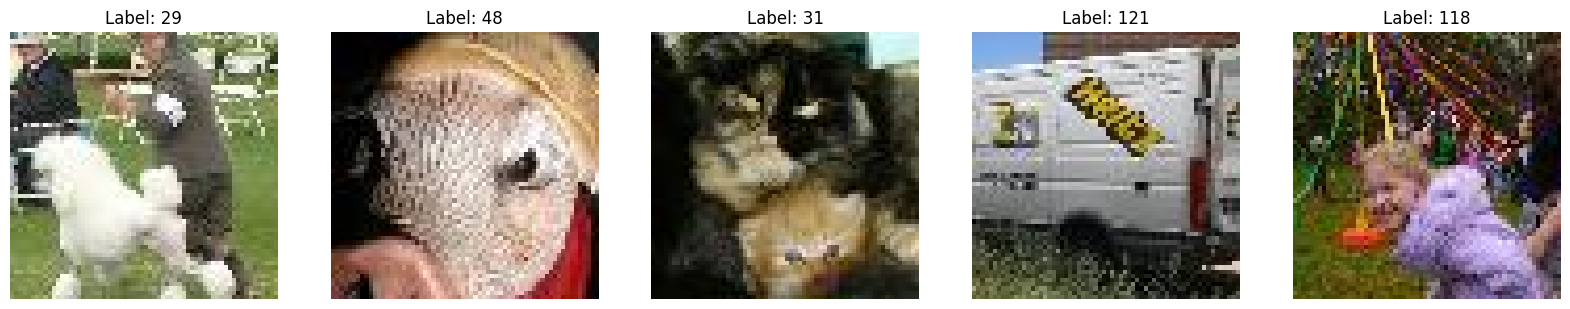

In [13]:
# Plotting the first few images in the batch
images, labels = next(iter(train_loader_64))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

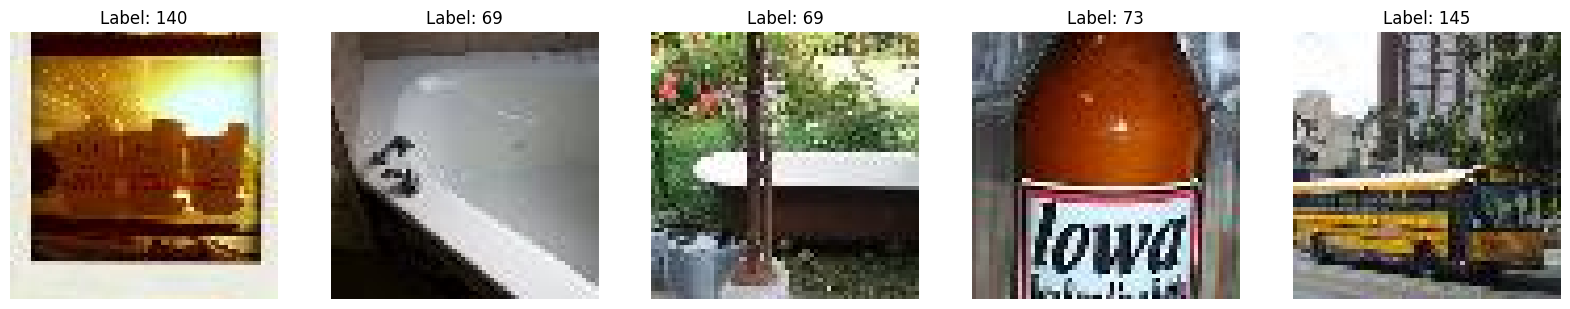

In [14]:
# Plotting the first few images in the batch
images, labels = next(iter(val_loader_64))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

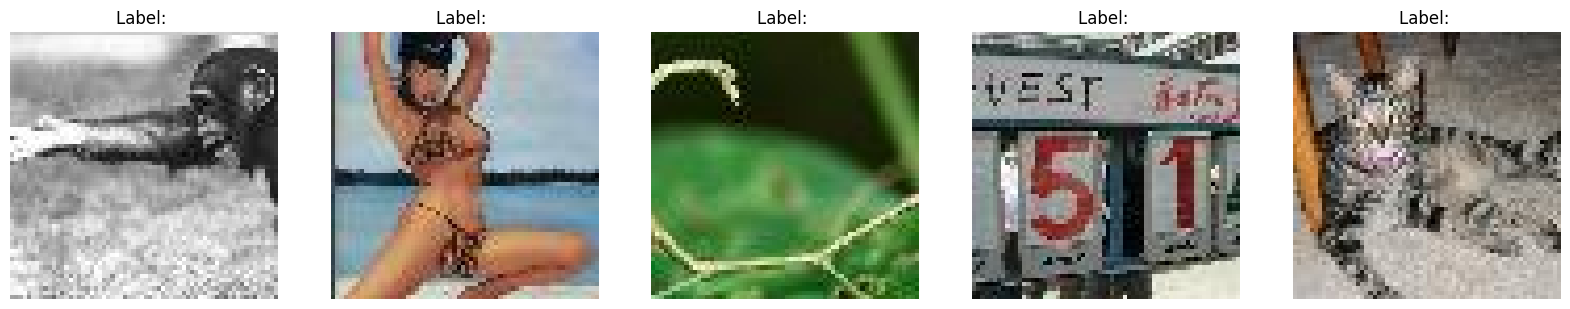

In [15]:
# Plotting the first few images in the batch
images = next(iter(test_loader_64))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: ")
plt.show()

# 2. Training utilities

Create the functions needed to train and evaluate both models.

## Requirements

Use:

- `cuda` when available;
- `CrossEntropyLoss`;
- a training loop;
- a validation loop.

For every epoch, record:

- training loss;
- training accuracy;
- validation loss;
- validation accuracy.

Use the **same validation set** for both models.

> Keep the first FCNN-vs-CNN comparison reasonably fair. For example, start with the same number of epochs before introducing additional CNN improvements.

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

criterion = nn.CrossEntropyLoss()


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

Using device: cuda


# 3. Model 1 — Fully Connected Neural Network (FCNN)

Build a neural network that classifies the images **without using convolutional layers**.

Conceptually:

```text
image [3, 128, 128]
        ↓
      Flatten
        ↓
      Linear
        ↓
      ReLU
        ↓
       ...
        ↓
      Linear
        ↓
    200 logits
```

## Requirements

- Do **not** use `nn.Conv1d`, `nn.Conv2d`, or `nn.Conv3d`.
- Use `Flatten`.
- Use at least one hidden `Linear` layer.
- Use a nonlinear activation such as `ReLU`.
- Produce exactly **200 logits**.
- Report the number of trainable parameters.

Before implementing the model, calculate:

$$
3 \times 128 \times 128
$$

and consider what this means for the size of the first fully connected layer.

In [17]:
#  Model 1: FCNN / MLP
#
# class FCNN(nn.Module):
#     ...
#
# model_fcnn = FCNN(...).to(device)
#
# Print the model and the number of trainable parameters.

## 3.1 Train and evaluate the FCNN

Train the FCNN using the training set and evaluate it on the validation set after each epoch.

Record your results.

| Model | Parameters | Epochs | Best Train Acc. | Best Val. Acc. | Best Val. Loss |
|---|---:|---:|---:|---:|---:|
| FCNN |  |  |  |  |  |

### Questions

1. How many trainable parameters does your FCNN have?
2. Which layer contains most of them?
3. What happens to the explicit spatial structure of the image after `Flatten`?
4. Does this architecture reuse the same weights to detect a feature at different image locations?

In [18]:
# Train Model 1
#
# optimizer_fcnn = ...
# history_fcnn = ...
#
# Train the model and store its metrics.

# 4. Model 2 — Convolutional Neural Network (CNN)

Now build a model that explicitly exploits spatial structure.

Conceptually:

```text
image
  ↓
Conv2d → ReLU → Pool
  ↓
Conv2d → ReLU → Pool
  ↓
...
  ↓
classifier
  ↓
200 logits
```

## Requirements

Your CNN must:

- contain `nn.Conv2d`;
- use nonlinear activations;
- reduce or aggregate spatial information;
- end with **200 logits**;
- report the number of trainable parameters.

You may decide:

- number of convolutional blocks;
- number of filters;
- kernel sizes;
- pooling strategy;
- classifier dimensions.

First obtain a working baseline. Later you may experiment with `BatchNorm2d`, `Dropout`, additional augmentation, schedulers, or other improvements.

In [23]:
class CNN64(nn.Module):
    
    def __init__(self, num_classes=200, dropout=0.3):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2),
            )

        self.features = nn.Sequential(
            conv_block(3, 64),     # 64x64 -> 32x32
            conv_block(64, 128),   # 32x32 -> 16x16
            conv_block(128, 256),  # 16x16 -> 8x8
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


model_cnn64 = CNN64(num_classes=200).to(device)
print(model_cnn64)

num_params_cnn64 = count_trainable_params(model_cnn64)
print(f"\nTrainable parameters (CNN64): {num_params_cnn64:,}")

sample_images, _ = next(iter(train_loader_64))
sample_images = sample_images.to(device)
with torch.no_grad():
    sample_logits = model_cnn64(sample_images)
print("Logits shape:", sample_logits.shape)
assert sample_logits.shape[1] == 200

CNN64(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, s

## 4.1 Train and evaluate the CNN

Train the CNN and evaluate it using **the same validation set** used for Model 1.

For the initial comparison, avoid changing many experimental conditions at once. Once you have a valid FCNN-vs-CNN baseline, you can improve the CNN for the competition.

| Model | Parameters | Epochs | Best Train Acc. | Best Val. Acc. | Best Val. Loss |
|---|---:|---:|---:|---:|---:|
| CNN |  |  |  |  |  |

### Questions

1. Which model obtains the best validation accuracy?
2. Which model has more parameters?
3. How large is the gap between training and validation accuracy?
4. Is there evidence of overfitting?
5. Why are convolutions better suited than a fully connected first layer for image data?

In [24]:
def train_one_epoch_amp(model, loader, optimizer, criterion, device, scaler):
    model.train()
    loss_sum = torch.zeros(1, device=device)
    correct_sum = torch.zeros(1, device=device)
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.detach() * images.size(0)
        correct_sum += (outputs.argmax(dim=1) == labels).sum()
        total += labels.size(0)

    return (loss_sum.item() / total), (correct_sum.item() / total)


@torch.no_grad()
def evaluate_amp(model, loader, criterion, device):
    model.eval()
    loss_sum = torch.zeros(1, device=device)
    correct_sum = torch.zeros(1, device=device)
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            outputs = model(images)
            loss = criterion(outputs, labels)

        loss_sum += loss.detach() * images.size(0)
        correct_sum += (outputs.argmax(dim=1) == labels).sum()
        total += labels.size(0)

    return (loss_sum.item() / total), (correct_sum.item() / total)

In [ ]:
import time

EPOCHS_CNN64 = 25
LR_CNN64 = 1e-3
WEIGHT_DECAY_CNN64 = 1e-4
BEST_CNN64_PATH = str(WORK_DIR.parent / "best_cnn64.pt")

# Reiniciamos el modelo desde cero para que el cosine scheduler
# se calibre correctamente sobre las 54 epochs completas
model_cnn64 = CNN64(num_classes=200).to(device)
num_params_cnn64 = count_trainable_params(model_cnn64)
print(f"Trainable parameters (CNN64): {num_params_cnn64:,}")

optimizer_cnn64 = torch.optim.AdamW(
    model_cnn64.parameters(), lr=LR_CNN64, weight_decay=WEIGHT_DECAY_CNN64
)
scheduler_cnn64 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cnn64, T_max=EPOCHS_CNN64
)

scaler64 = torch.amp.GradScaler("cuda")
model_cnn64 = model_cnn64.to(device, memory_format=torch.channels_last)

history_cnn64 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_cnn64 = 0.0
start_time = time.time()

for epoch in range(1, EPOCHS_CNN64 + 1):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch_amp(
        model_cnn64, train_loader_64, optimizer_cnn64, criterion, device, scaler64
    )
    val_loss, val_acc = evaluate_amp(model_cnn64, val_loader_64, criterion, device)
    scheduler_cnn64.step()

    history_cnn64["train_loss"].append(train_loss)
    history_cnn64["train_acc"].append(train_acc)
    history_cnn64["val_loss"].append(val_loss)
    history_cnn64["val_acc"].append(val_acc)

    if val_acc > best_val_acc_cnn64:
        best_val_acc_cnn64 = val_acc
        torch.save(model_cnn64.state_dict(), BEST_CNN64_PATH)

    epoch_time = time.time() - epoch_start
    print(
        f"Epoch {epoch:02d}/{EPOCHS_CNN64} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={epoch_time:.1f}s"
    )

training_time_cnn64 = time.time() - start_time
print(f"\nTotal training time (CNN64): {training_time_cnn64:.1f} s")

# Restaurar el mejor checkpoint
model_cnn64.load_state_dict(torch.load(BEST_CNN64_PATH))

best_train_acc_cnn64 = max(history_cnn64["train_acc"])
best_val_loss_cnn64 = min(history_cnn64["val_loss"])

print("\n| Model | Parameters | Epochs | Best Train Acc. | Best Val. Acc. | Best Val. Loss |")
print("|---|---:|---:|---:|---:|---:|")
print(
    f"| CNN64 | {num_params_cnn64:,} | {EPOCHS_CNN64} | "
    f"{best_train_acc_cnn64:.4f} | {best_val_acc_cnn64:.4f} | {best_val_loss_cnn64:.4f} |"
)

In [21]:
epochs_range = range(1, EPOCHS_CNN64 + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history_cnn64["train_loss"], label="Train")
axes[0].plot(epochs_range, history_cnn64["val_loss"], label="Val")
axes[0].set_title("CNN64 — Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history_cnn64["train_acc"], label="Train")
axes[1].plot(epochs_range, history_cnn64["val_acc"], label="Val")
axes[1].set_title("CNN64 — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

NameError: name 'EPOCHS_CNN64' is not defined

In [ ]:
import json

baseline_summary = {
    "num_params": num_params_cnn64,
    "training_time": training_time_cnn64,
    "best_val_acc": best_val_acc_cnn64,
    "best_val_loss": best_val_loss_cnn64,
    "history": history_cnn64,
}

with open(WORK_DIR.parent / "cnn64_extended_summary.json", "w") as f:
    json.dump(baseline_summary, f)

# 5. Compare FCNN vs CNN

Complete the table using your experiments.

| Property | FCNN | CNN |
|---|---:|---:|
| Trainable parameters |  |  |
| Best training accuracy |  |  |
| Best validation accuracy |  |  |
| Best validation loss |  |  |
| Training time |  |  |

## Analysis

Answer briefly:

1. What is the main architectural difference between the two models?
2. Which model generalizes better according to the validation set?
3. Does the model with more parameters necessarily perform better?
4. What advantage does **local connectivity** give a CNN?
5. What is **weight sharing**, and why is it useful?
6. Is there evidence of overfitting in either model?
7. Which model will you use as the basis for your competition submission, and why?

In [ ]:
# Run this once both history_fcnn/model_fcnn (Section 3) and
# history_cnn/model_cnn (Section 4) exist, to auto-fill the Section 5 table
# with real computed numbers 

required_vars = ["history_fcnn", "num_params_fcnn", "training_time_fcnn",
                  "history_cnn", "num_params_cnn", "training_time_cnn"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    print("Still missing to auto-fill the comparison table:", missing)
else:
    best_train_acc_fcnn = max(history_fcnn["train_acc"])
    best_val_acc_fcnn = max(history_fcnn["val_acc"])
    best_val_loss_fcnn = min(history_fcnn["val_loss"])

    best_train_acc_cnn = max(history_cnn["train_acc"])
    best_val_acc_cnn = max(history_cnn["val_acc"])
    best_val_loss_cnn = min(history_cnn["val_loss"])

    print("| Property | FCNN | CNN |")
    print("|---|---:|---:|")
    print(f"| Trainable parameters | {num_params_fcnn:,} | {num_params_cnn:,} |")
    print(f"| Best training accuracy | {best_train_acc_fcnn:.4f} | {best_train_acc_cnn:.4f} |")
    print(f"| Best validation accuracy | {best_val_acc_fcnn:.4f} | {best_val_acc_cnn:.4f} |")
    print(f"| Best validation loss | {best_val_loss_fcnn:.4f} | {best_val_loss_cnn:.4f} |")
    print(f"| Training time (s) | {training_time_fcnn:.1f} | {training_time_cnn:.1f} |")

Still missing to auto-fill the comparison table: ['history_fcnn', 'num_params_fcnn', 'training_time_fcnn', 'history_cnn', 'num_params_cnn', 'training_time_cnn']


# 6. Improve your CNN

After completing the required FCNN-vs-CNN comparison, improve your CNN for the competition.

Possible experiments:

- number of convolutional blocks;
- number of filters;
- kernel size;
- pooling;
- `BatchNorm2d`;
- `Dropout`;
- optimizer;
- learning rate;
- learning-rate scheduler;
- data augmentation;
- number of epochs.

Change the design **systematically** and use validation performance to decide whether a modification helps.

> The public leaderboard is feedback, not your validation set.

In [25]:
# Mejoramos la transformación de entrenamiento incluyendo:
# Recorte aleatorio
# Eliminación aleatoria de partes de la imagen (Random Erasing)
# Cambios de color

train_transform_v2 = transforms.Compose([
    transforms.RandomResizedCrop(64, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.25),
])

train_dataset_64v2 = CSVImageDataset(train_df, TRAIN_DIR, transform=train_transform_v2)

# DataLoaders
train_loader_64v2 = DataLoader(
    train_dataset_64v2, batch_size=256, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2,
)

In [26]:
#Se añade bloque residual al modelo para mejorar la capacidad de aprendizaje permitiendo mayor flujo del gradiente evitando desvanecimiento.
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)

class CNN64v2(nn.Module):
    def __init__(self, num_classes=200, dropout=0.4):
        super().__init__()
        def down(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.stem = down(3, 64)          # 64->32
        self.stage1 = nn.Sequential(down(64, 128), ResidualBlock(128))    # 32->16
        self.stage2 = nn.Sequential(down(128, 256), ResidualBlock(256))  # 16->8
        self.stage3 = nn.Sequential(down(256, 512), ResidualBlock(512)) # 8->4
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout), nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        return self.classifier(x)

In [ ]:
import time
import gc

# Liberar memoria del run anterior (CNN64) antes de entrenar v2.
# No borra history_cnn64 ni los checkpoints en disco.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

EPOCHS_CNN64V2 = 60
LR_CNN64V2 = 1e-3
WEIGHT_DECAY_CNN64V2 = 4e-4
BEST_CNN64V2_PATH = str(WORK_DIR.parent / "best_cnn64v2.pt")

# Reiniciamos el modelo desde cero para que el cosine scheduler
# se calibre correctamente sobre todas las epochs
model_cnn64v2 = CNN64v2(num_classes=200).to(device)
num_params_cnn64v2 = count_trainable_params(model_cnn64v2)

print(f"\nTrainable parameters (CNN64v2): {num_params_cnn64v2:,}")

optimizer_cnn64v2 = torch.optim.AdamW(
    model_cnn64v2.parameters(), lr=LR_CNN64V2, weight_decay=WEIGHT_DECAY_CNN64V2
)
scheduler_cnn64v2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cnn64v2, T_max=EPOCHS_CNN64V2
)

scaler64v2 = torch.amp.GradScaler("cuda")
model_cnn64v2 = model_cnn64v2.to(device, memory_format=torch.channels_last)

history_cnn64v2 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_cnn64v2 = 0.0
start_time = time.time()

for epoch in range(1, EPOCHS_CNN64V2 + 1):
    epoch_start = time.time()
    train_loss, train_acc = train_one_epoch_amp(
        model_cnn64v2, train_loader_64v2, optimizer_cnn64v2, criterion, device, scaler64v2
    )
    val_loss, val_acc = evaluate_amp(model_cnn64v2, val_loader_64, criterion, device)
    scheduler_cnn64v2.step()

    history_cnn64v2["train_loss"].append(train_loss)
    history_cnn64v2["train_acc"].append(train_acc)
    history_cnn64v2["val_loss"].append(val_loss)
    history_cnn64v2["val_acc"].append(val_acc)

    if val_acc > best_val_acc_cnn64v2:
        best_val_acc_cnn64v2 = val_acc
        torch.save(model_cnn64v2.state_dict(), BEST_CNN64V2_PATH)

    epoch_time = time.time() - epoch_start
    print(
        f"Epoch {epoch:02d}/{EPOCHS_CNN64V2} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={epoch_time:.1f}s"
    )

training_time_cnn64v2 = time.time() - start_time
print(f"\nTotal training time (CNN64v2): {training_time_cnn64v2:.1f} s")

# Restaurar el mejor checkpoint
model_cnn64v2.load_state_dict(torch.load(BEST_CNN64V2_PATH))

best_train_acc_cnn64v2 = max(history_cnn64v2["train_acc"])
best_val_loss_cnn64v2 = min(history_cnn64v2["val_loss"])

print("\n| Model | Parameters | Epochs | Best Train Acc. | Best Val. Acc. | Best Val. Loss |")
print("|---|---:|---:|---:|---:|---:|")
print(
    f"| CNN64v2 | {num_params_cnn64v2:,} | {EPOCHS_CNN64V2} | "
    f"{best_train_acc_cnn64v2:.4f} | {best_val_acc_cnn64v2:.4f} | {best_val_loss_cnn64v2:.4f} |"
)


Trainable parameters (CNN64v2): 7,851,272
Epoch 01/60 | train_loss=4.6600 train_acc=0.0574 | val_loss=4.2603 val_acc=0.0888 | time=127.6s
Epoch 02/60 | train_loss=3.9329 train_acc=0.1390 | val_loss=3.8930 val_acc=0.1380 | time=127.6s
Epoch 03/60 | train_loss=3.5302 train_acc=0.2025 | val_loss=3.3373 val_acc=0.2355 | time=125.2s
Epoch 04/60 | train_loss=3.2563 train_acc=0.2505 | val_loss=3.4274 val_acc=0.2353 | time=125.6s
Epoch 05/60 | train_loss=3.0314 train_acc=0.2945 | val_loss=2.9535 val_acc=0.3020 | time=126.8s
Epoch 06/60 | train_loss=2.8573 train_acc=0.3263 | val_loss=2.7598 val_acc=0.3472 | time=125.2s


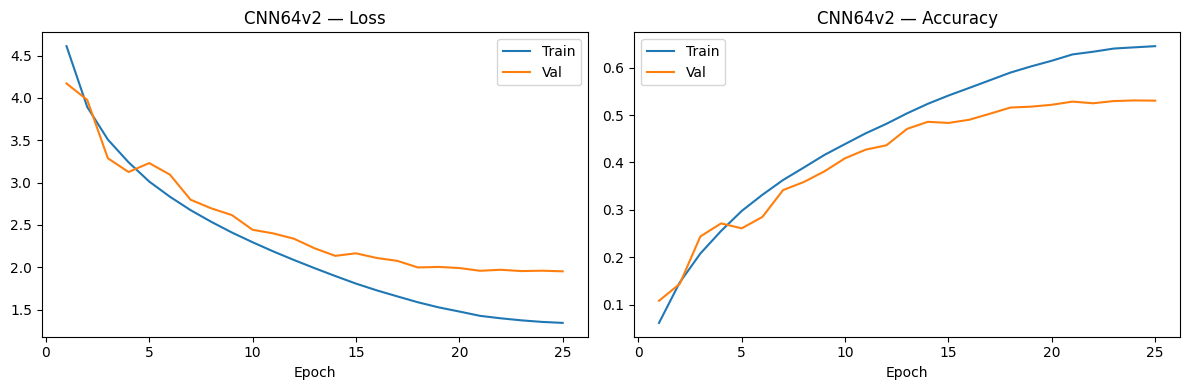

In [ ]:
epochs_range = range(1, EPOCHS_CNN64V2 + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history_cnn64v2["train_loss"], label="Train")
axes[0].plot(epochs_range, history_cnn64v2["val_loss"], label="Val")
axes[0].set_title("CNN64v2 — Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history_cnn64v2["train_acc"], label="Train")
axes[1].plot(epochs_range, history_cnn64v2["val_acc"], label="Val")
axes[1].set_title("CNN64v2 — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()